# **CABAgent: <ins>C</ins>omprehensive Layout-Aware <ins>A</ins>nalog <ins>B</ins>enchmark Generation via Self-Improving LLM <ins>Agent</ins>s for Analog Circuit Design Automation**

| Name                    | Affiliation                                                                                          | IEEE Member | SSCS Member |
|:-----------------------:|:----------------------------------------------------------------------------------------------------:|:-----------:|:-----------:|
| Jinhai Hu*              | Institute of Microelectronics, A*STAR, Singapore                                                     | Yes         | Yes         |
| Jiageng Wang*           | Nanyang Technological University, Singapore                                                          | No          | No          |
| Xinzhe Xie              | Nanyang Technological University, Singapore; <br /> Institute of Microelectronics, A*STAR, Singapore | Yes         | Yes         |
| Zhixuan Bao             | Nanyang Technological University, Singapore                                                          | No          | No          |
| Wang Ling Goh           | Nanyang Technological University, Singapore                                                          | Yes         | Yes         |
| Xiaoli Li               | Singapore University of Technology and Design (SUTD)                                                 | Yes         | No          |
| Xinrun Wang             | Singapore Management University (SMU)                                                                | No          | No          |
| Xun Xu                  | Institute for Infocomm Research, A*STAR, Singapore                                                   | No          | No          |
| Zhuoyi Lin              | Institute for Infocomm Research, A*STAR, Singapore                                                   | No          | No          |
| Yuan Gao                | Institute of Microelectronics, A*STAR, Singapore                                                     | Yes         | Yes         |

## Abstract

The lack of comprehensive, layout-verified benchmarks remains a major bottleneck for AI-powered analog circuit design automation. Existing studies often focus on schematic-level circuit generation or optimization under simplified device assumptions, without foundry PDK integration, physical verification, or post-layout evaluation, thereby limiting reproducibility and practical relevance. This paper presents CABAgent, a comprehensive layout-aware analog benchmark generation framework driven by self-evolving LLM agents. Starting from natural-language circuit descriptions, interface constraints, and PDK information, CABAgent first generates validated SKY130-compatible SPICE netlists through a training-free multi-agent loop that couples circuit generation, static netlist checking, Ngspice-based validation, reflection, and knowledge curation. It then expands each validated seed into standardized benchmark packages by automatically exploring device sizing, bias conditions, and layout constraints, followed by pre-layout simulation, automatic layout generation, DRC/LVS verification, parasitic extraction, and post-layout evaluation. Using Gemini, the front end achieves 84.0% Pass@1 and 99.8% Pass@5 on analog circuit generation tasks. In its current implementation, CABAgent generates 20 circuit topologies and 1,000 benchmark packages within 10 hours. By producing reproducible multi-view artifacts that pair circuit intent, physical implementation, verification evidence, and pre-/post-layout performance labels, CABAgent provides a practical foundation for reproducible evaluation and future learning-based analog design research.

<hr style="border:2px solid grey">

## Setup

### Prerequisites (Linux)
The following open-source EDA tools are required:
- **[ngspice](http://ngspice.sourceforge.net/)** - circuit simulator
- **[KLayout](https://www.klayout.de/)** - layout viewer and DRC
- **[Magic](http://opencircuitdesign.com/magic)** - layout and parasitic extraction
- **[Netgen](http://opencircuitdesign.com/netgen)** - LVS verification
- **[SKY130 PDK](https://github.com/RTimothyEdwards/open_pdks)** - open-source foundry PDK

Install ngspice and KLayout via apt:
```bash
sudo apt update && sudo apt install ngspice klayout
```
Magic, Netgen, and open_pdks should be built from source following the [README](README.md).

### Clone with Submodules
```bash
git clone --recurse-submodules https://github.com/HUJH511/sscs-ose-code-a-chip.github.io
```

### Python Dependencies

In [ ]:
# Install required Python packages
%pip install openai python-dotenv matplotlib numpy pandas

### API Key
Create a `.env` file in the notebook directory:
```
GEMINI_API_KEY=your_key_here
```

<hr style="border:2px solid grey">

## Introduction

Automated analog circuit design remains a challenging task in modern IC development, requiring extensive domain expertise, iterative optimization across multiple performance metrics, and careful consideration of device-level and layout-dependent effects. As shown in Fig. 1, recent advances in machine learning (ML) and AI have significantly improved several key aspects of analog design automation [1], [2], including circuit sizing [3], [4], layout generation [5], [6], [7], and parasitics-aware modeling [8], [9], through the use of reinforcement learning (RL) [10], [11], Bayesian optimization (BO) [12], [13], graph neural network (GNN)-based methods [14], [15]. However, a key gap remains: most LLM-assisted circuit generation approaches are still limited to schematic-level design without foundry PDK integration or physical verification, limiting practical relevance and reproducibility.  

In parallel, large language models (LLMs) and agent-based frameworks have recently been explored for analog circuit synthesis, topology generation, and design automation from high-level descriptions [16]-[19]. Notably, recent systems such as AnalogCoder [20], AnalogXpert [22], and AnalogAgent [23] suggest a new paradigm for flexible, natural-language-driven analog design, where training-free multi-agent systems generate analog circuits through iterative feedback and knowledge reuse.

Despite these advances, a critical gap remains: the lack of layout-verified benchmarks for AI-powered analog design automation. Existing datasets are typically netlist-centric and do not support physically realistic evaluation across the full design flow [28], [29]. To address this, CABAgent integrates LLM-driven netlist generation with a PDK-compatible end-to-end EDA flow, producing physically verified benchmark packages that pair circuit intent, layout, verification evidence, and pre-/post-layout performance labels.

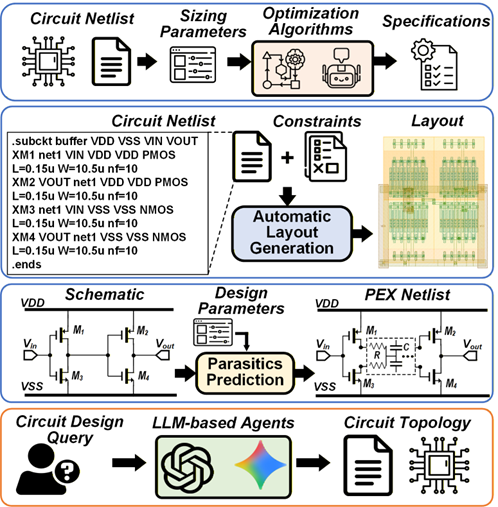

<hr style="border:2px solid grey">

## Architecture

CABAgent is a unified two-stage architecture that bridges natural-language circuit intent and physically verified analog benchmark packages. The first stage, AnalogAgent+, extends AnalogAgent into a PDK-aware transistor-level netlist synthesis engine, in which a Code Generator, Design Optimizer, and Knowledge Curator cooperate through a self-evolving memory (SEM) to translate natural-language circuit descriptions into foundry PDK-compatible (e.g. SKY130 [30]) transistor-level SPICE netlists and their associated parameter space. Retrieved rules from SEM refine the generation prompt, while static netlist checking and Ngspice-based operating-point verification provide execution-grounded feedback for iterative correction. In the second stage, the validated seed netlist is processed by a comprehensive analog benchmark generator (CABGen), which samples device and testbench parameters, applies optional layout constraints, and executes pre-layout simulation, automatic layout generation, physical verification, parasitic extraction, and post-layout simulation. As a result, CABAgent produces a standardized multi-view benchmark package that couples circuit intent, physical implementation, verification evidence, and paired pre-/post-layout labels within a reproducible artifact structure.

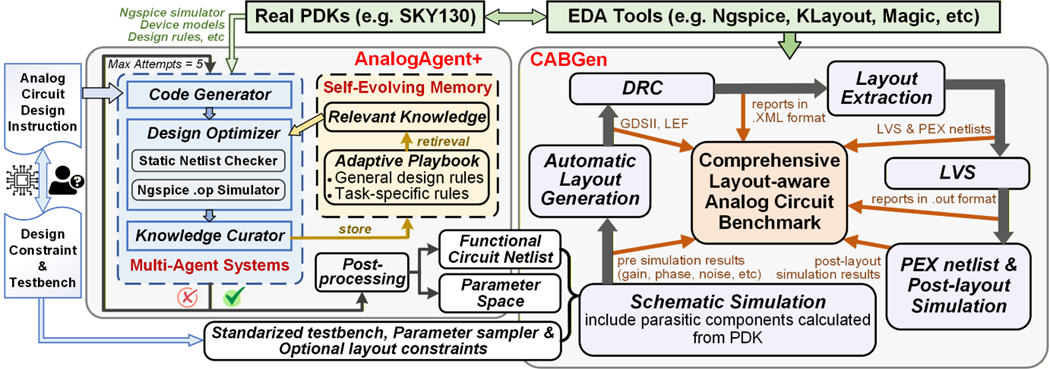

The following figure illustrates the experimental flow of CABAgent from natural-language circuit description to standardized benchmark package. Given a task prompt and interface constraints, AnalogAgent+ iterates a multi-agent loop with retrieved rules from SEM injected as reusable guidance for subsequent iterations. The validated netlists are then processed by CABGen through parameter and layout-constraint sampling, followed by automatic simulation and verification pipeline. As a result, the output of the framework is not an isolated circuit description, but a benchmark package that jointly contains circuit-definition artifacts, physical implementation views, verification reports, and paired pre-/post-layout measurement labels under a unified schema. The experiments in this section are organized in two parts: first, a front-end evaluation of AnalogAgent+ on analog design tasks; second, a layout-aware benchmark-generation study across multiple circuit classes, parameter settings, and tool configurations.

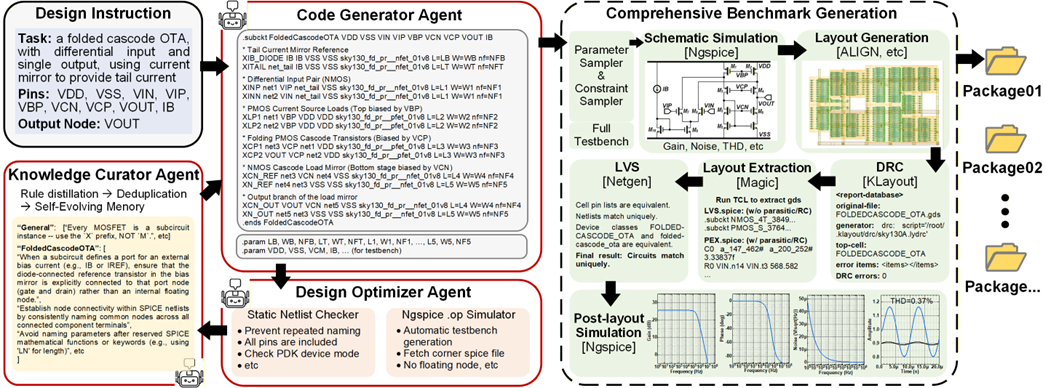

<hr style="border:2px solid grey">

## Step 1: LLM-Driven Netlist Generation (AnalogAgent)

AnalogAgent takes a **natural-language circuit description** and generates a **SKY130 PDK-compatible SPICE subcircuit netlist** through an agentic loop:

1. **Code Generator** — LLM generates a `.subckt` netlist from prompt + SEM guidance
2. **Design Optimizer** — Runs static checks and ngspice DC validation; reflects on failures
3. **Knowledge Curator** — Distills failure/success into reusable rules (Self-Evolving Memory)

The generated netlist is then post-processed (device renaming, param splitting) and fed into the CABGen pipeline below.

<hr style="border:2px solid grey">

The **Code Generator** produces a candidate SKY130-compatible SPICE subcircuit from the task description, interface constraints, and retrieved SEM guidance. The **Design Optimizer** evaluates each candidate through a two-level validation flow: a static netlist checker that screens for structural violations (invalid model names, incorrect device prefixes, floating internal nodes, missing bias paths), followed by an Ngspice operating-point verification step that checks whether the circuit admits a feasible DC solution. When validation fails, the **Knowledge Curator** converts the failed candidate and its execution evidence into reusable design rules, which are written back to the Self-Evolving Memory (SEM) to guide subsequent iterations.


#### Test case 1: Five-Transistor OTA

A five-transistor OTA with differential input and single output, using a 1:1 current mirror to provide tail current. This topology serves as the baseline demonstration for the full CABAgent pipeline.

In [1]:
from src.analogagent import generate_netlist

In [ ]:
# --- Generate SKY130 netlist for Five-Transistor OTA ---
result_ota5t = generate_netlist(
    task="a five-transistor OTA, with differential input and single output, "
         "using 1:1 current mirror to provide tail current",
    pins="VDD, VSS, VIN, VIP, VOUT, IB",
    output_node="VOUT",
    output_dir="designs/OTA_5T/SKY130/inputs",
    max_retries=5,
)

print(f"\nSuccess: {result_ota5t['success']}")
print(f"Iterations used: {result_ota5t['iterations']}")
if result_ota5t['raw_code']:
    print(f"\n--- Generated Netlist ---")
    print(result_ota5t['raw_code'])

[AnalogAgent] Connected to Gemini API. Model: gemini-2.5-flash
[AnalogAgent] SEM guidance injected for type: OTA
[Generator] Generating code... Mode: CREATE
IN RUN_CODE (ngspice) : /tmp/tmpm_nckvtg_tb.sp
num of stdout lines: 212
num of stderr lines: 1
---- STDOUT (last 40 lines) ----
        exp         -         -         -
        pwl         -         -         -
       sffm         -         -         -
         am         -         -         -
    trnoise         -         -         -
   trrandom         -         -         -
          i                     0                     0           9.98833e-05
          p                     0                     0                     0

 Vsource: Independent voltage source
     device                  vvdd
         dc                   1.8
      acmag                     0
      pulse         -
        sin         -
        exp         -
        pwl         -
       sffm         -
         am         -
    trnoise         -
   trrandom  

## Step 2: Layout-Aware Benchmark Generation (CABGen)

With the generated netlist in place, the CABGen pipeline takes over:

1. **Pre-simulation** — Embed netlist into testbench, run Ngspice AC/noise/transient analysis
2. **Layout generation** — Convert netlist to ALIGN format, generate GDS layout
3. **Verification** — DRC (KLayout), parasitic extraction (Magic), LVS (Netgen)
4. **Post-simulation** — Re-run simulations with extracted parasitics

This is repeated across multiple parameter combinations to build a comprehensive benchmark.

<hr style="border:2px solid grey">

Each instantiated design first undergoes **pre-layout simulation** using real SKY130-compatible device models, providing physically grounded performance labels even before explicit parasitic extraction. **Automatic layout generation** is then performed via ALIGN or GLayout, producing GDS and LEF views. The generated layout is subjected to **DRC** (KLayout) and **LVS** (Netgen) verification to ensure geometric compliance and electrical consistency. **Parasitic extraction** (Magic) yields an extracted netlist, which is re-simulated under the same testbench to obtain post-layout metrics. The resulting benchmark package pairs circuit intent, physical implementation, verification evidence, and pre-/post-layout performance labels under a unified schema.


In [7]:
from src.design_pipeline import EDAPipeline

In [8]:
DEFAULT_PDK = "SKY130"

DEFAULT_STEPS = {
    "pre-sim"   : "Ngspice",
    "layout"    : "ALIGN",
    "drc"       : "KLayout",
    "extract"   : "Magic",
    "lvs"       : "Netgen",
    "post-sim"  : "Ngspice",
}

DEFAULT_RESET = {
    "keep_top"  : {"align", "klayout", "magic", "netgen", "ngspice"},
    "keep_path" : {"align": {"0_netlist"}, "ngspice": {".spiceinit", "param.spice"}},
    "verbose"   : False,
}

In [ ]:
pipeline = EDAPipeline("OTA_5T", pdk=DEFAULT_PDK, steps=DEFAULT_STEPS, reset_kwargs=DEFAULT_RESET)

Design configuration loaded:
 design  :
   name       : OTA_5T
   circuit    : five_transistor_ota
   pin_order  : VDD VSS VIN VIP VOUT IB
   top_module : FIVE_TRANSISTOR_OTA_0
 paths   :
   root : designs/OTA_5T/SKY130
 inputs  :
   netlist_file : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_5T/SKY130/inputs/ckt_netlist.spice
   param_file   : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_5T/SKY130/inputs/ckt_param.spice
   const_file   : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_5T/SKY130/inputs/constraints.json
   tb_file      : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_5T/SKY130/inputs/testbench.spice
 align   :
   input_dir  : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_5T/SKY130/runs/align/0_netlist
   sky130_dir : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks

In [10]:
pipeline.run_cabgen(num_trials=10)

INFO: PIPELINE: Starting Benchmark Generation for OTA_5T
Preserved: /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_5T/SKY130/runs/align/0_netlist
Preserved: /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_5T/SKY130/runs/ngspice/param.spice
Preserved: /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_5T/SKY130/runs/ngspice/.spiceinit
Replaced: align input netlist with CAB-generated param.spice
INFO: RESET: Workspace reset for benchmark generation trail 0
[PRE-SIM] → Ngspice
INFO: NGSPICE: ngspice -b /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_5T/SKY130/runs/ngspice/five_transistor_ota_presim.spice
INFO: NGSPICE: Simulation Finished! Please check logs/ngspice.log for details.
[LAYOUT] → ALIGN
INFO: ALIGN: schematic2layout.py /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_5T/SKY130/runs/align/0_netlist 

## Results and Discussion

The following test cases demonstrate CABAgent across representative analog circuit topologies, validating the framework's generalization beyond the baseline OTA.


#### Test case 2: Telescopic OTA

A ten-transistor telescopic cascoded OTA with differential input and single output, using a 1:1 current mirror for tail current and tunable cascode bias voltages VCN and VCP.


In [ ]:
# --- Generate SKY130 netlist for Telescopic OTA ---
result_ota_tc = generate_netlist(
    task="a ten transistor telescopic cascoded OTA, with differential input and single output"
         "using 1:1 current mirror to provide tail current,"
         "enabling tunable bias voltages VCN and VCP",
    pins="VDD, VSS, VIN, VIP, VCN, VCP, VOUT, IB",
    output_node="VOUT",
    output_dir="designs/OTA_TC/SKY130/inputs",
    max_retries=5,
)

print(f"\nSuccess: {result_ota_tc['success']}")
print(f"Iterations used: {result_ota_tc['iterations']}")
if result_ota_tc['raw_code']:
    print(f"\n--- Generated Netlist ---")
    print(result_ota_tc['raw_code'])

[AnalogAgent] Connected to Gemini API. Model: gemini-2.5-flash
[AnalogAgent] SEM guidance injected for type: TelescopicOTA
[Generator] Generating code... Mode: CREATE
IN RUN_CODE (ngspice) : /tmp/tmp5t3x7tyb_tb.sp
num of stdout lines: 7
num of stderr lines: 5
---- STDOUT (last 40 lines) ----

No compatibility mode selected!


Circuit: * auto-generated testbench for telescopic_ota_10t


---- STDOUT END ----
---- STDERR (last 40 lines) ----
Error: unknown subckt: xdut.xout vout xdut.net7 0 0 v_dummy
    Simulation interrupted due to error!

Note: No ".plot", ".print", or ".fourier" lines; no simulations run

---- STDERR END ----
[AnalogAgent] iter=0  exec_err=1  sim_err=0  warning=0
[Playbook] Recorded failure for Task general, Iter 0
[Auto-Curator] Requesting analysis (Text only)...
[Auto-Curator] Candidate new rule: All SPICE 'X' statements must instantiate a subcircuit that is properly defined elsewhere in the netlist or included via a library; do not use 'X' statements for primitive 

In [9]:
pipeline = EDAPipeline("OTA_TC", pdk=DEFAULT_PDK, steps=DEFAULT_STEPS, reset_kwargs=DEFAULT_RESET)

Design configuration loaded:
 design  :
   name       : OTA_TC
   circuit    : telescopic_ota
   pin_order  : VDD VSS VIN VIP VCN VCP VOUT IB
   top_module : TELESCOPIC_OTA_0
 paths   :
   root : designs/OTA_TC/SKY130
 inputs  :
   netlist_file : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_TC/SKY130/inputs/ckt_netlist.spice
   param_file   : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_TC/SKY130/inputs/ckt_param.spice
   const_file   : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_TC/SKY130/inputs/constraints.json
   tb_file      : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_TC/SKY130/inputs/testbench.spice
 align   :
   input_dir  : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_TC/SKY130/runs/align/0_netlist
   sky130_dir : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/C

In [10]:
pipeline.run_cabgen(num_trials=10)

INFO: PIPELINE: Starting Benchmark Generation for OTA_TC
Preserved: /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_TC/SKY130/runs/align/0_netlist
Preserved: /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_TC/SKY130/runs/ngspice/param.spice
Preserved: /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_TC/SKY130/runs/ngspice/.spiceinit
Replaced: align input netlist with CAB-generated param.spice
INFO: RESET: Workspace reset for benchmark generation trail 0
[PRE-SIM] → Ngspice
INFO: NGSPICE: ngspice -b /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_TC/SKY130/runs/ngspice/telescopic_ota_presim.spice
INFO: NGSPICE: Simulation Finished! Please check logs/ngspice.log for details.
[LAYOUT] → ALIGN
INFO: ALIGN: schematic2layout.py /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_TC/SKY130/runs/align/0_netlist -p /h

Some layouts and performance metrics from various packages are shown below

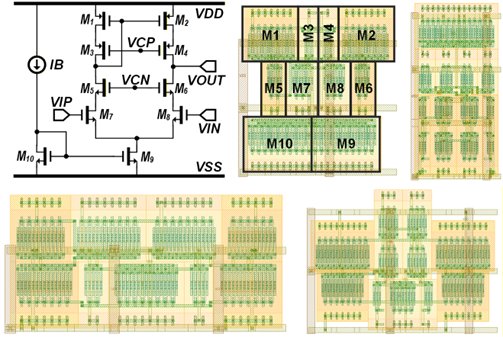

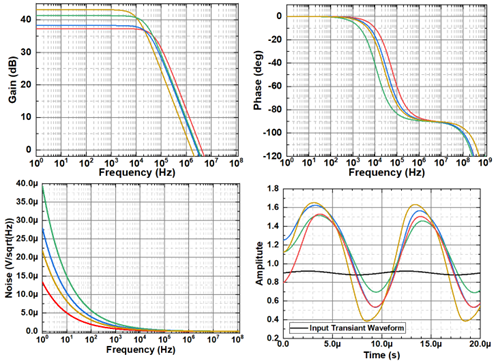

#### Test case 3: Folded Cascode OTA

A folded cascode OTA with differential input and single output. Compared to the telescopic topology, the folded structure extends the output voltage swing by routing the cascode branches through a complementary fold.


In [ ]:
# --- Generate SKY130 netlist for Folded Cascode OTA ---
result_ota_fc = generate_netlist(
    task="a folded cascode OTA, with differential input and single output, "
         "using 1:1 current mirror to provide tail current",
    pins="VDD, VSS, VIN, VIP, VBP, VCN, VCP, VOUT, IB",
    output_node="VOUT",
    output_dir="designs/OTA_FC/SKY130/inputs",
    max_retries=5,
    gemini_model="gemini-3-flash-preview"
)

print(f"\nSuccess: {result_ota_fc['success']}")
print(f"Iterations used: {result_ota_fc['iterations']}")
if result_ota_fc['raw_code']:
    print(f"\n--- Generated Netlist ---")
    print(result_ota_fc['raw_code'])

[AnalogAgent] Connected to Gemini API. Model: gemini-3-flash-preview
[AnalogAgent] SEM guidance injected for type: FoldedCascodeOTA
[Generator] Generating code... Mode: CREATE
IN RUN_CODE (ngspice) : /tmp/tmpq2a0tvt6_tb.sp
num of stdout lines: 8
num of stderr lines: 75
---- STDOUT (last 40 lines) ----

No compatibility mode selected!


Circuit: * auto-generated testbench for folded_cascode_ota

 Copies=41 Evals=129 Placeholders=4 Symbols=22 Errors=32

---- STDOUT END ----
---- STDERR (last 40 lines) ----
Cannot compute substitute
Original line no.: 0, new internal line no.: 46:
 Expression err: ln
Original line no.: 0, new internal line no.: 46:
 Formula() error.
      l=ln; w=wn; nf=nfn;
Original line no.: 0, new internal line no.: 19:
Undefined number [l]
Original line no.: 0, new internal line no.: 19:
Cannot compute substitute
Original line no.: 0, new internal line no.: 47:
 Expression err: ln
Original line no.: 0, new internal line no.: 47:
 Formula() error.
      l=ln; w=wn; nf=

In [10]:
pipeline = EDAPipeline("OTA_FC", pdk=DEFAULT_PDK, steps=DEFAULT_STEPS, reset_kwargs=DEFAULT_RESET)

Design configuration loaded:
 design  :
   name       : OTA_FC
   circuit    : foldedcascode_ota
   pin_order  : VDD VSS VIN VIP VCN VCP VBP VOUT IB
   top_module : FOLDEDCASCODE_OTA_0
 paths   :
   root : designs/OTA_FC/SKY130
 inputs  :
   netlist_file : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_FC/SKY130/inputs/ckt_netlist.spice
   param_file   : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_FC/SKY130/inputs/ckt_param.spice
   const_file   : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_FC/SKY130/inputs/constraints.json
   tb_file      : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_FC/SKY130/inputs/testbench.spice
 align   :
   input_dir  : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_FC/SKY130/runs/align/0_netlist
   sky130_dir : /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_n

In [12]:
pipeline.run_cabgen(num_trials=10)

INFO: PIPELINE: Starting Benchmark Generation for OTA_FC
Preserved: /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_FC/SKY130/runs/ngspice/param.spice
Preserved: /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_FC/SKY130/runs/ngspice/.spiceinit
Preserved: /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_FC/SKY130/runs/align/0_netlist
Replaced: align input netlist with CAB-generated param.spice
INFO: RESET: Workspace reset for benchmark generation trail 0
[PRE-SIM] → Ngspice
INFO: NGSPICE: ngspice -b /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_FC/SKY130/runs/ngspice/foldedcascode_ota_presim.spice
INFO: NGSPICE: Simulation Finished! Please check logs/ngspice.log for details.
[LAYOUT] → ALIGN
INFO: ALIGN: schematic2layout.py /home/sscs-ose-code-a-chip.github.io/VLSI26/submitted_notebooks/CABAgent/designs/OTA_FC/SKY130/runs/align/0_netlist -p

#### Test case 4: Long-Arm Comparator

A high-speed comparator with a pre-amplification stage followed by a regenerative latch, used to evaluate CABAgent on non-OTA analog circuits.


<hr style="border:2px solid grey">

## Conclusion

This work presents CABAgent, a framework that adopts training-free self-evolving LLM agents within a configurable, PDK-compatible analog design flow to generate physically verified, layout-aware analog benchmark packages and datasets. Starting from natural-language circuit descriptions, CABAgent produces validated SPICE netlists and expands them into standardized multi-view artifacts spanning pre-layout simulation, automatic layout generation, DRC/LVS verification, parasitic extraction, and post-layout evaluation. The resulting packages provide paired electrical and physical views under a reproducible interface, while the modular pipeline supports alternative tools, parameter sweeps, and layout constraints. CABAgent therefore provides a practical and scalable foundation for future large circuit model training, fine-tuning, and reasoning under physically grounded conditions.

<hr style="border:2px solid grey">

## References

[1] G. Gielen and R. Rutenbar, "Computer-aided design of analog and mixed-signal integrated circuits," *Proc. IEEE*, vol. 88, no. 12, pp. 1825–1854, 2000.

[2] L. Massier et al., "The sizing rules method for CMOS and bipolar analog integrated circuit design," *IEEE TCAD*, vol. 9, no. 12, pp. 1263–1271, 1990.

[3] B. Liu et al., "Gaspad: A general and efficient analog circuit synthesis framework," *IEEE DAC*, 2013.

[4] W. Lyu et al., "Batch Bayesian optimization via multi-objective acquisition ensemble for automated analog circuit design," in *ICML*, 2018.

[5] K. Xu et al., "ALIGN: Open-source analog layout automation from the ground up," in *IEEE ISSCC*, 2019.

[6] H. Chen et al., "MAGICAL: Toward fully automated analog IC layout leveraging human and machine intelligence," in *IEEE ICCAD*, 2019.

[7] P.-H. Chen et al., "LAYGO2: Automatic layout generation for custom circuits in advanced technology nodes," *IEEE TCAD*, 2023.

[8] A. Levy et al., "Learning-based parasitic extraction and post-layout performance prediction," in *IEEE DAC*, 2021.

[9] J. Hu et al., "Parasitic-aware layout generation for analog circuits using graph-based methods," *IEEE TCAD*, 2023.

[20] Y. Liao et al., "AnalogCoder: Analog circuit design via training-free code generation," in *NeurIPS*, 2024.

[22] Z. He et al., "AnalogXpert: Automating analog topology synthesis using domain-specific large language model agents," *arXiv:2412.19824*, 2024.

[23] Y. Liao et al., "AnalogAgent: Self-improving analog circuit design automation with LLM agents," in *KDD*, 2026.

[24] X. Yang et al., "SPICEPilot: Navigating SPICE code generation and simulation with AI guidance," *arXiv:2410.20553*, 2024.

[30] S. Sriram et al., "SKY130 process design kit," SkyWater Technology, Open-source PDK, 2020. [Online]. Available: https://github.com/google/skywater-pdk

[35] T. Aichholzer, "KLayout — High performance layout viewer and editor," [Online]. Available: https://www.klayout.de

[36] T. Edwards, "Magic VLSI layout tool," [Online]. Available: http://opencircuitdesign.com/magic

[37] T. Edwards, "Netgen LVS tool," [Online]. Available: http://opencircuitdesign.com/netgen
